In [ ]:

# -----------------------------------------------------------------------------
# Prediction-only calibration & evaluation using the UNION approach with PATH
# calibration (tube-consistent): for each scene, we ask whether there exists a
# *single* tube k such that the truth stays inside that tube's per-time ellipses
# for ALL horizons. Calibration proceeds in two stages:
#   (1) Per-horizon UNION calibration via closed-form quantiles:
#       s_t(α) = sqrt( Quantile_α( min_k M2[i,k,t] / τ_α ) )
#       where M2[i,k,t] = (y_true_{i,t} - mu_{i,k,t})^T S_{i,k,t}^{-1} (y_true_{i,t} - mu_{i,k,t}).
#   (2) PATH multiplier γ(α) via closed-form quantiles:
#       γ_req(i;α) = sqrt( min_k max_t ( M2[i,k,t] / s_t(α)^2 ) / τ_α ),
#       γ(α) = Quantile_α( γ_req(i;α) ).
#
# This file removes MPC/policy-specific code; it only evaluates the *set-level*
# "exists tube" semantics for prediction displays.
#
# -----------------------------------------------------------------------------

import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ------------------------------
# Config / toggles
# ------------------------------
SEED = 1
np.random.seed(SEED); torch.manual_seed(SEED)

# Trajectory length and dimensionality
T = 10
D = 2 * T

# Synthetic mixture size (for data generation only)
# K = 3
K = 2

# Number of candidate tubes per scene (the "union of tubes" size)
NUM_TUBES = 50            # increase for denser coverage; costs scale ~O(n_scenes * NUM_TUBES)

# Scenario and terminal anchoring
# baseline is an easier scenario with increasing variance with 3 modes
# mid_peak is a harder scenario with variance peaking in the middle. there are 3+2 = 5 modes.
SCENARIO = "mid_peak"     # "baseline" or "mid_peak"
ANCHOR_END = (SCENARIO == "mid_peak")
END_SIGMA = np.array([0.008, 0.008])  # anchor std per axis if ANCHOR_END=True

# Teacher + regularization
USE_SCORENET_TEACHER = False #Original: True           # we use a score network.
USE_EPSNET_TEACHER = True # Try using epsnet

SIGMA_MIN = 0.005
SIGMA_MAX = 0.5
SIGMA_EVALS = [0.005, 0.01, 0.02]       # probe small σ for sharper curvature
WHITEN = True
CURVATURE_FLOOR = 0.1                   # adds δ·u to HVP target (caps covariance); can be lower, e.g., 0.05

# Numerics (kept from v6 for stability)
WOODBURY_JITTER = 1e-5                  # ε added to (I + R^T A^{-1} R) ; jitter should be around 1e-6 or 1e-5
PRECISION_RIDGE = 1e-7                  # A <- L L^T + λI (prefer this over block ridge); for numerical stability
BLOCK_RIDGE = 0.0                       # optional block ridge on 2x2 marginals
EIGEN_FLOOR = 1e-9                      # PSD floor for 2x2 marginals

# α-grid for calibration
ALPHAS_GRID = np.array([0.50, 0.70, 0.80, 0.90, 0.95])

# Low-rank tail for long-range couplings
USE_LOW_RANK_TAIL = True
RANK_R = 10
LAMBDA_R_SMOOTH = 1e-3
LAMBDA_R_L2     = 3e-4

# DEVICE = torch.device("cpu")
DEVICE = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
print(DEVICE)

# Training steps (you can reduce for quick tests)
DSM_STEPS = 80000
DSM_BATCH = 512
DSM_LR    = 1e-4

PH_STEPS  = 1000
PH_BATCH  = 128
PH_PROBES = 4
PH_LR     = 3e-3

# Mixture weights (which modes to mix from)
# MIX_WEIGHTS = np.array([0.45, 0.30, 0.25], dtype=np.float64)
MIX_WEIGHTS = np.array([0.45, 0.55], dtype=np.float64)


# ------------------------------
# Synthetic mixture (Gaussian chain + anchor)
# ------------------------------
def process_noise_Q(t_index: int, mode: int) -> np.ndarray:
    if SCENARIO == "baseline":
        base_x = 0.03 + 0.010 * t_index
        base_y = 0.02 + 0.015 * t_index
    elif SCENARIO == "mid_peak":
        center = 0.5 * (T + 1)
        width  = 0.22 * T
        bump   = math.exp(- ((t_index - center) ** 2) / (2.0 * width ** 2))
        base_x = 0.03 + 0.015 * bump
        base_y = 0.03 + 0.020 * bump
    else:
        raise ValueError("Unknown SCENARIO")
    if mode in (1, 2):   # turns → more lateral uncertainty
        base_y *= 1.35
    return np.array([[base_x, 0.0],[0.0, base_y]], dtype=np.float64)

def mean_path(mode: int, T: int, v: float = 0.5, dtheta: float = 0.09) -> np.ndarray:
    x, y, theta = 0.0, 0.0, 0.0; pts = []
    for _ in range(T):
        if mode == 1:   theta += dtheta
        elif mode == 2: theta -= dtheta
        x += v * math.cos(theta); y += v * math.sin(theta)
        pts.append([x, y])
    return np.array(pts, dtype=np.float64).reshape(-1)

def build_mode_parameters(mode: int):
    mu = mean_path(mode, T)
    Q_inv = [np.linalg.inv(process_noise_Q(t, mode)) for t in range(1, T+1)]
    J = np.zeros((D, D), dtype=np.float64)
    for t in range(T):
        if t == 0:      J_block = Q_inv[0] + Q_inv[1]
        elif t == T-1:  J_block = Q_inv[T-1]
        else:           J_block = Q_inv[t] + Q_inv[t+1]
        i = 2*t; J[i:i+2, i:i+2] = J_block
    for t in range(T-1):
        i = 2*t; j = 2*(t+1)
        J[i:i+2, j:j+2] = -Q_inv[t+1]; J[j:j+2, i:i+2] = -Q_inv[t+1]
    eta = J @ mu
    if ANCHOR_END:
        R_end = np.diag(END_SIGMA**2); Rinv = np.linalg.inv(R_end); idx = slice(D-2, D)
        J[idx, idx] = J[idx, idx] + Rinv; eta[idx] = eta[idx] + Rinv @ mu[idx]
    J = 0.5*(J+J.T) + 1e-9*np.eye(D)
    L = np.linalg.cholesky(J)
    m = np.linalg.solve(L.T, np.linalg.solve(L, eta))
    return m, J, L

MODES = [build_mode_parameters(m) for m in range(K)]


def logpdf_mode(y, m, J):
    d = y - m
    return -0.5*float(d @ (J @ d))

def logp_mixture(y_flat):
    vals = [logpdf_mode(y_flat, m, J) + np.log(MIX_WEIGHTS[k]+1e-16)
            for k,(m,J,_L) in enumerate(MODES)]
    m = np.max(vals)
    return m + np.log(np.sum(np.exp(np.array(vals) - m)))

def sample_mode(mode, n):
    m, J, L = MODES[mode]
    X = np.zeros((n, D), dtype=np.float64)
    for i in range(n):
        z = np.random.randn(D)
        delta = np.linalg.solve(L.T, z)
        X[i] = m + delta
    return X

def sample_mixture(n):
    counts = np.random.multinomial(n, MIX_WEIGHTS)
    chunks = []
    for m in range(K):
        c = counts[m]
        if c>0: chunks.append(sample_mode(m, c))
    X = np.concatenate(chunks, axis=0) if chunks else np.zeros((0,D), dtype=np.float64)
    idx = np.random.permutation(len(X))
    return X[idx], None


# ------------------------------
# Whitening
# ------------------------------

W_VEC = np.ones(D, dtype=np.float64)

def fit_whitener(n_fit=10000):
    global W_VEC
    X, _ = sample_mixture(n_fit)
    std = X.std(axis=0) + 1e-6
    W_VEC = 1.0 / std
    print("[WHITEN] median std:", float(np.median(std)), "min:", float(std.min()), "max:", float(std.max()))

def whiten(X): return X * W_VEC

def unwhiten(X): return X / W_VEC

def unwhiten_block(S_white, t):
    D_t = np.diag(1.0 / W_VEC[2*t:2*t+2])
    return D_t @ S_white @ D_t

# ------------------------------
# ScoreNet (whitened)
# ------------------------------
'''
class ScoreNet(nn.Module):
    def __init__(self, D, hidden=384):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(D+2, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, D)
        )
    def forward(self, y, sigma):
        log_sig = torch.log(sigma).unsqueeze(1)
        feat = torch.cat([y, log_sig, sigma.unsqueeze(1)], dim=1)
        return self.net(feat)

def train_scorenet(Xpool):
    model = ScoreNet(D).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=DSM_LR)
    # Xpool, _ = sample_mixture(25000)
    Xpool = whiten(Xpool) if WHITEN else Xpool
    Xpool_t = torch.from_numpy(Xpool).float().to(DEVICE)
    def sample_sigma(batch):
        u = torch.rand(batch, device=DEVICE)
        log_min, log_max = math.log(SIGMA_MIN), math.log(SIGMA_MAX)
        return torch.exp(log_min + u*(log_max - log_min))
    hist = []
    for step in range(1, DSM_STEPS+1):
        idx = np.random.choice(Xpool_t.shape[0], size=DSM_BATCH, replace=False)
        x0 = Xpool_t[idx]; sigma = sample_sigma(x0.shape[0])
        z = torch.randn_like(x0); x = x0 + sigma.view(-1,1)*z
        target = - z / sigma.view(-1,1)
        s_pred = model(x, sigma)
        w = (sigma**2).view(-1,1)
        loss = torch.mean(w * (s_pred - target)**2)
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if step % 1000 == 0 or step == DSM_STEPS:
            print(f"[DSM {step:4d}] loss={float(loss.item()):.4e}")
        hist.append(float(loss.item()))
    return model, np.array(hist)

# --------------------------
# 4. Sampling function
# --------------------------
@torch.no_grad()
def sample(model, n_samples=10, n_steps=500):
    model.eval()
    y = torch.randn(n_samples, T*2, device=DEVICE)

    sigmas = torch.exp(torch.linspace(np.log(SIGMA_MAX), np.log(SIGMA_MIN), n_steps, device=DEVICE))

    for sigma in sigmas:
        sigma_batch = torch.full((n_samples,), sigma, device=DEVICE)
        grad = model(y, sigma_batch)

        # ✅ Step size tuned
        # epsilon = (sigma**2) * 0.5
        epsilon = torch.tensor((sigma**2) * 0.0001, device=DEVICE)
        # epsilon = torch.tensor(0.00001, device=DEVICE)
        z = torch.randn_like(y, device=DEVICE)

        y = y + epsilon * grad + torch.sqrt(2 * epsilon) * z

    y = unwhiten(y.cpu().numpy())
    return y  # (n_samples, T*2)
'''

class EpsNet(nn.Module):
    def __init__(self, D, hidden=384):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(D+2, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, D)
        )
    def forward(self, y, sigma):
        # y: (batch, D), sigma: (batch,)
        log_sig = torch.log(sigma).unsqueeze(1)               # (batch,1)
        feat = torch.cat([y, log_sig, sigma.unsqueeze(1)], 1) # (batch, D+2)
        return self.net(feat)  # predict epsilon (same shape as y)

def train_epsnet(Xpool):
    model = EpsNet(D).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=DSM_LR)
    # Xpool, _ = sample_mixture(25000)
    Xpool = whiten(Xpool) if WHITEN else Xpool
    Xpool_t = torch.from_numpy(Xpool).float().to(DEVICE)

    def sample_sigma(batch):
        u = torch.rand(batch, device=DEVICE)
        log_min, log_max = math.log(SIGMA_MIN), math.log(SIGMA_MAX)
        return torch.exp(log_min + u*(log_max - log_min))

    hist = []
    for step in range(1, DSM_STEPS+1):
        idx = np.random.choice(Xpool_t.shape[0], size=DSM_BATCH, replace=False)
        x0 = Xpool_t[idx]
        sigma = sample_sigma(x0.size(0))   # (batch,)
        eps = torch.randn_like(x0)         # ground truth ε
        x = x0 + sigma.view(-1,1) * eps    # noisy sample

        eps_hat = model(x, sigma)
        loss = ((eps_hat - eps)**2).mean()

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if step % 1000 == 0 or step == DSM_STEPS:
            print(f"[EPS {step:4d}] loss={loss.item():.4e}")
        hist.append(loss.item())
    return model, np.array(hist)

@torch.no_grad()
def sample(model, n_samples=10, n_steps=500):
    model.eval()
    y = torch.randn(n_samples, T*2, device=DEVICE)

    sigmas = torch.exp(torch.linspace(np.log(SIGMA_MAX), np.log(SIGMA_MIN), n_steps, device=DEVICE))

    for sigma in sigmas:
        sigma_batch = torch.full((n_samples,), sigma, device=DEVICE)
        eps_hat = model(y, sigma_batch)
        score = - eps_hat / sigma_batch.view(-1,1)  # convert noise → score

        # annealed Langevin step
        epsilon = (sigma**2) * 0.5
        z = torch.randn_like(y)
        y = y + epsilon * score + torch.sqrt(2*epsilon) * z

    y = unwhiten(y.cpu().numpy())
    return y

def hvp_from_scorenet(score_net, y_white, sigma_evals, u):
    h_acc = torch.zeros_like(y_white)
    for σ in sigma_evals:
        sigma_eval = torch.full((y_white.shape[0],), fill_value=σ, device=y_white.device, dtype=y_white.dtype)
        y_req = y_white.detach().clone().requires_grad_(True)
        s = score_net(y_req, sigma_eval)
        su = (s * u).sum()
        h = torch.autograd.grad(su, y_req, create_graph=False)[0]
        h_acc = h_acc + h
    h_acc = h_acc / float(len(sigma_evals))
    if CURVATURE_FLOOR > 0.0:
        h_acc = h_acc + float(CURVATURE_FLOOR) * u
    return h_acc

'''
hvp if using epsnet
'''
def hvp_from_epsnet(eps_net, y_white, sigma_evals, u):
    h_acc = torch.zeros_like(y_white)
    for σ in sigma_evals:
        sigma_eval = torch.full(
            (y_white.shape[0],), fill_value=σ,
            device=y_white.device, dtype=y_white.dtype
        )
        y_req = y_white.detach().clone().requires_grad_(True)

        # 1. Predict noise
        eps_hat = eps_net(y_req, sigma_eval)

        # 2. Convert noise → score
        s = - eps_hat / sigma_eval.view(-1, *([1] * (y_white.ndim - 1)))
        su = (s * u).sum()
        h = torch.autograd.grad(su, y_req, create_graph=False)[0]
        h_acc = h_acc + h

    # Average across sigmas
    h_acc = h_acc / float(len(sigma_evals))

    # Curvature floor (damping)
    if CURVATURE_FLOOR > 0.0:
        h_acc = h_acc + float(CURVATURE_FLOOR) * u

    return h_acc



# ------------------------------
# Precision head
# ------------------------------
class PrecisionHead(nn.Module):
    def __init__(self, D, T, hidden=220, use_low_rank=False, rank_r=2):
        super().__init__()
        self.D = D; self.T = T; self.use_low_rank = use_low_rank; self.rank_r = rank_r
        self.backbone = nn.Sequential(
            nn.Linear(D, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU()
        )
        self.out_diag = nn.Linear(hidden, 3*T)
        self.out_sub  = nn.Linear(hidden, 4*(T-1)) if T>1 else None
        self.out_R    = nn.Linear(hidden, D*rank_r) if (use_low_rank and rank_r>0) else None
        self.eps = 3e-3
    def forward(self, y):
        B = y.shape[0]
        h = self.backbone(y)
        diag = self.out_diag(h)
        sub  = self.out_sub(h) if self.out_sub is not None else None
        Rmat = self.out_R(h)   if self.out_R   is not None else None
        Ls, Rs = [], []
        for b in range(B):
            L = torch.zeros(self.D, self.D, dtype=y.dtype, device=y.device)
            d = diag[b]
            for t in range(self.T):
                a11 = F.softplus(d[3*t + 0]) + self.eps
                a21 = d[3*t + 1]
                a22 = F.softplus(d[3*t + 2]) + self.eps
                i = 2*t
                L[i+0, i+0] = a11
                L[i+1, i+0] = a21
                L[i+1, i+1] = a22
            if sub is not None:
                s = sub[b]
                for t in range(1, self.T):
                    i = 2*t; j = 2*(t-1)
                    L[i+0, j+0] = s[4*(t-1)+0]
                    L[i+1, j+0] = s[4*(t-1)+1]
                    L[i+0, j+1] = s[4*(t-1)+2]
                    L[i+1, j+1] = s[4*(t-1)+3]
            Ls.append(L)
            if (self.out_R is not None) and (Rmat is not None):
                Rs.append(Rmat[b].view(self.D, self.rank_r))
            else:
                Rs.append(None)
        return Ls, Rs


# ------------------------------
# Train precision head (HVP self-consistency)
# ------------------------------
def temporal_smoothness_penalty(Rb):
    if Rb is None: return 0.0
    r = Rb.shape[1]; loss = 0.0
    for k in range(r):
        col = Rb[:, k].view(T, 2); diff = col[1:] - col[:-1]
        loss += (diff**2).sum()
    return loss / (r * max(1, T-1))

def train_precision_head(teacher=None):
    head = PrecisionHead(D, T, hidden=220, use_low_rank=USE_LOW_RANK_TAIL, rank_r=RANK_R).to(DEVICE)
    opt = torch.optim.Adam(head.parameters(), lr=PH_LR)
    Xpool, _ = sample_mixture(8000)
    Xpool = whiten(Xpool) if WHITEN else Xpool
    Xpool_t = torch.from_numpy(Xpool).float().to(DEVICE)
    hist = []
    for step in range(1, PH_STEPS+1):
        idx = np.random.choice(Xpool_t.shape[0], size=PH_BATCH, replace=False)
        yb = Xpool_t[idx]
        L_list, R_list = head(yb)
        loss_prec = 0.0; loss_reg = 0.0
        for _ in range(PH_PROBES):
            u = torch.randn_like(yb)
            if teacher is None:
                raise NotImplementedError("Use ScoreNet teacher under whitening.")
            # h = hvp_from_scorenet(teacher, yb, SIGMA_EVALS, u)
            h = hvp_from_epsnet(teacher, yb, SIGMA_EVALS, u)
            Lu_total = []
            for b in range(yb.shape[0]):
                Lb = L_list[b]; tmp = Lb.t().matmul(u[b]); Au  = Lb.matmul(tmp)
                if USE_LOW_RANK_TAIL and (R_list[b] is not None):
                    Rb = R_list[b]; Au = Au + Rb.matmul(Rb.t().matmul(u[b]))
                Lu_total.append(Au)
            Lu_total = torch.stack(Lu_total, dim=0)
            loss_prec = loss_prec + F.mse_loss(Lu_total + h, torch.zeros_like(h))
        loss_prec = loss_prec / PH_PROBES
        if USE_LOW_RANK_TAIL:
            for b in range(yb.shape[0]):
                Rb = R_list[b]
                if Rb is not None:
                    loss_reg = loss_reg + LAMBDA_R_L2 * (Rb**2).sum() + LAMBDA_R_SMOOTH * temporal_smoothness_penalty(Rb)
        loss = loss_prec + loss_reg
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(head.parameters(), 1.0)
        opt.step()
        hist.append(float(loss_prec.item()))
        if step % 100 == 0 or step == PH_STEPS:
            print(f"[PH {step:4d}] L_prec={hist[-1]:.4e}  (reg≈{float(loss_reg.item()) if torch.is_tensor(loss_reg) else loss_reg:.2e})")
    return head, np.array(hist)


# ------------------------------
# Stable covariance from (L,R) and 2x2 marginals
# ------------------------------
def full_cov_from_factors_np(L_t: torch.Tensor, R_t, precision_ridge=PRECISION_RIDGE, woodbury_jitter=WOODBURY_JITTER) -> np.ndarray:
    """
    Compute dense Σ = (L L^T + λI + R R^T)^-1 via Woodbury.
    Returns Σ as a (D,D) numpy float64.
    """
    L = L_t.detach().cpu().numpy().astype(np.float64)
    A = L @ L.T
    if precision_ridge > 0.0:
        A = A + float(precision_ridge) * np.eye(L.shape[0], dtype=np.float64)
    # Cholesky for A
    Ld = np.linalg.cholesky(A)
    # A^{-1}
    I = np.eye(L.shape[0], dtype=np.float64)
    Ainv = np.linalg.solve(Ld.T, np.linalg.solve(Ld, I))
    if (R_t is None) or (R_t.numel() == 0):
        return Ainv
    R = R_t.detach().cpu().numpy().astype(np.float64)
    AinvR = np.linalg.solve(Ld.T, np.linalg.solve(Ld, R))
    RtAinvR = R.T @ AinvR
    M = RtAinvR + np.eye(R.shape[1], dtype=np.float64)
    M = 0.5*(M + M.T) + float(woodbury_jitter) * np.eye(M.shape[0], dtype=np.float64)
    B = np.linalg.solve(M, np.eye(M.shape[0], dtype=np.float64))  # (I + RtAinvR)^{-1}
    Sigma = Ainv - AinvR @ B @ AinvR.T
    Sigma = 0.5*(Sigma + Sigma.T)
    return Sigma

def blocks_from_cov_np(Sigma: np.ndarray) -> np.ndarray:
    """Extract 2x2 diagonal blocks [T,2,2] from a (D,D) covariance."""
    out = np.zeros((T, 2, 2), dtype=np.float64)
    for t in range(T):
        i = 2*t
        S = Sigma[i:i+2, i:i+2]
        # Optional block ridge applied in covariance space via precision transform
        if BLOCK_RIDGE > 0.0:
            Sinv = np.linalg.inv(S)
            S = np.linalg.inv(Sinv + float(BLOCK_RIDGE) * np.eye(2, dtype=np.float64))
        # PSD clamp
        w, V = np.linalg.eigh(0.5*(S + S.T))
        w = np.clip(w, EIGEN_FLOOR, None)
        S = (V * w) @ V.T
        out[t] = S
    return out


# ------------------------------
# Candidate generation (diversified union)
# ------------------------------
def generate_scenes(n_scenes, num_tubes, diversify=True, pool_factor=25,
                    diversify_mode: str = "waypoints", waypoint_idxs=None):
    """
    Returns:
      Yp: [n_scenes, num_tubes, D]  candidate trajectories per scene (mixture-only)
      Yt: [n_scenes, D]             ground-truth per scene (mixture draw; independent)
    Diversification is performed *without* using Yt (no leakage):
      - Draw a large pool from the mixture; build features φ per candidate (end-point or waypoints).
      - Greedy farthest-point on φ to pick num_tubes diverse candidates.
    """
    # Ground-truths
    Yt = np.zeros((n_scenes, D), dtype=np.float64)
    for i in range(n_scenes): Yt[i] = sample_mixture(1)[0][0]

    # Default waypoint set
    if diversify_mode == "waypoints" and waypoint_idxs is None:
        waypoint_idxs = [T//3, 2*T//3, T-1]

    # Helper: greedy farthest subset
    def farthest_subset(feat: np.ndarray, m: int) -> list:
        N = feat.shape[0]
        chosen = [int(np.random.randint(N))]
        while len(chosen) < m:
            d2 = np.min([np.sum((feat - feat[j])**2, axis=1) for j in chosen], axis=0)
            d2[chosen] = -1.0
            chosen.append(int(np.argmax(d2)))
        return chosen

    # Candidates per scene
    Yp = np.zeros((n_scenes, num_tubes, D), dtype=np.float64)
    for i in range(n_scenes):
        if not diversify:
            cand, _ = sample_mixture(num_tubes)
            Yp[i] = cand
        else:
            pool_N = max(num_tubes * pool_factor, num_tubes)
            pool, _ = sample_mixture(pool_N)
            traj = pool.reshape(-1, T, 2)
            if diversify_mode == "end":
                feat = traj[:, -1, :]
            elif diversify_mode == "waypoints":
                idxs = [j for j in waypoint_idxs if 0 <= j < T]
                if len(idxs) == 0: idxs = [T-1]
                feat = traj[:, idxs, :].reshape(pool_N, -1)
            else:
                raise ValueError("diversify_mode must be 'end' or 'waypoints'")
            chosen = farthest_subset(feat, num_tubes)
            Yp[i] = pool[chosen]
    return Yp, Yt


# ------------------------------
# Precompute base M2 for union calibration (vectorized + batched)
# ------------------------------
def eval_head_factors_batched(head, Yw_flat, batch=2048):
    """
    Yw_flat: [N*M, D] whitened candidates.
    Returns lists Ls, Rs length N*M of torch tensors (float64).
    """
    head_dtype = next(head.parameters()).dtype if any(True for _ in head.parameters()) else torch.float32
    device = next(head.parameters()).device if any(True for _ in head.parameters()) else torch.device('cpu')
    Ls, Rs = [], []
    with torch.no_grad():
        for i0 in range(0, Yw_flat.shape[0], batch):
            yb = torch.from_numpy(Yw_flat[i0:i0+batch]).to(device=device, dtype=head_dtype)
            L_list, R_list = head(yb)
            # convert to float64 on CPU for numerics
            Ls.extend([L.to(torch.float64).cpu() for L in L_list])
            if USE_LOW_RANK_TAIL and (R_list is not None):
                Rs.extend([(R.to(torch.float64).cpu() if (R is not None) else None) for R in R_list])
            else:
                Rs.extend([None for _ in L_list])
    return Ls, Rs

def precompute_union_m2(head, n_scenes=360, num_tubes=NUM_TUBES, diversify=True,
                        diversify_mode="waypoints", batch=2048):
    """
    Returns:
      Yp: [N,M,D], Yt: [N,D]
      m2: [N,M,T] with M2[i,k,t] = diff^T S^{-1} diff (unwhitened units)
    """
    t0 = time.time()
    Yp, Yt = generate_scenes(n_scenes, num_tubes, diversify=diversify, diversify_mode=diversify_mode)
    # Whiten candidates for the head
    Yp_w = whiten(Yp.reshape(n_scenes, num_tubes, -1)) if WHITEN else Yp
    Yw_flat = Yp_w.reshape(-1, D)
    # Evaluate head in batches
    Ls, Rs = eval_head_factors_batched(head, Yw_flat, batch=batch)
    # For each candidate, build Σ, extract 2x2 blocks, unwhiten to S, invert with clamp
    m2 = np.zeros((n_scenes, num_tubes, T), dtype=np.float64)
    for idx in range(Yw_flat.shape[0]):
        i = idx // num_tubes
        k = idx %  num_tubes
        Sigma_w = full_cov_from_factors_np(Ls[idx], Rs[idx], precision_ridge=PRECISION_RIDGE, woodbury_jitter=WOODBURY_JITTER)
        S_blocks_w = blocks_from_cov_np(Sigma_w)  # [T,2,2] in whitened units
        # Unwhiten blocks and invert with eigen clamp
        diffs = Yt[i].reshape(T,2) - Yp[i,k].reshape(T,2)   # unwhitened diffs
        for t in range(T):
            S = unwhiten_block(S_blocks_w[t], t) if WHITEN else S_blocks_w[t]
            w, V = np.linalg.eigh(0.5*(S + S.T))
            w = np.clip(w, EIGEN_FLOOR, None)
            invS = (V * (1.0 / w)) @ V.T
            d = diffs[t]
            m2[i,k,t] = float(d @ (invS @ d)) # TODO: Add Transpose here: float(d.T @ (invS @ d))
    t1 = time.time()
    print(f"[PRECOMPUTE] Union m2 computed for {n_scenes} scenes x {num_tubes} tubes in {t1-t0:.2f}s")
    return Yp, Yt, m2


# ------------------------------
# UNION calibration (closed-form via quantiles)
# ------------------------------
def chi2_ppf_df2(alpha: float) -> float:
    return -2.0 * math.log(max(1e-16, 1.0 - float(alpha)))

def calibrate_union_per_horizon_quantile(m2: np.ndarray, alphas=ALPHAS_GRID) -> np.ndarray:
    """
    m2: [N,M,T] base Mahalanobis^2 (unscaled).
    Returns s_table[T, |alphas|] with per-horizon UNION scales via quantiles:
      s_t(α) = sqrt( quantile_α( min_k m2[:, :, t] / τ_α ) )
    """
    N, M, TT = m2.shape
    assert TT == T
    s_table = np.ones((T, len(alphas)), dtype=np.float64)
    Z = m2.min(axis=1)   # [N,T]
    for j, a in enumerate(alphas):
        tau = chi2_ppf_df2(a)
        # For each t, compute the α-quantile of Z[:,t]/tau
        q = np.quantile(Z / tau, a, axis=0, method="linear")
        s_table[:, j] = np.sqrt(np.maximum(q, 1e-16))
    return s_table

def calibrate_union_path_gamma_quantile(m2: np.ndarray, s_table: np.ndarray, alphas=ALPHAS_GRID) -> np.ndarray:
    """
    Given per-horizon s_table, compute γ(α) via closed-form quantiles:
      γ_req(i;α) = sqrt( min_k max_t ( m2[i,k,t] / s_t(α)^2 ) / τ_α )
      γ(α) = quantile_α( γ_req(i;α) ).
    Returns gamma_vec[|alphas|].
    """
    N, M, TT = m2.shape
    assert TT == T
    gamma = np.ones((len(alphas),), dtype=np.float64)
    for j, a in enumerate(alphas):
        tau = chi2_ppf_df2(a)
        s_vec = s_table[:, j]  # [T]
        denom = np.maximum(s_vec**2, 1e-16)
        # max over t, then min over k
        max_over_t = (m2 / denom[np.newaxis, np.newaxis, :]).max(axis=2)    # [N,M]
        min_over_k = max_over_t.min(axis=1)                                  # [N]
        gamma_req = np.sqrt(np.maximum(min_over_k / tau, 0.0))
        gamma[j] = float(np.quantile(gamma_req, a, method="linear"))
    return gamma


# ------------------------------
# UNION evaluation (path event)
# ------------------------------
def evaluate_union_path_from_m2(m2: np.ndarray, s_table: np.ndarray, gamma_vec: np.ndarray, alpha: float) -> float:
    """
    Empirical coverage of the union path event on a given m2 tensor (hold-out recommended):
      cov = (1/N) * |{ i : ∃k, ∀t  m2[i,k,t] / (γ(α)^2 s_t(α)^2) ≤ τ_α }|
    """
    tau = chi2_ppf_df2(alpha)
    # Interpolate s_vec if needed
    # Here alphas are fixed grid; use nearest in grid
    j = int(np.argmin(np.abs(ALPHAS_GRID - alpha)))
    s_vec = s_table[:, j]
    gamma = gamma_vec[j]
    denom = np.maximum((gamma**2) * (s_vec**2), 1e-16)
    max_over_t = (m2 / denom[np.newaxis, np.newaxis, :]).max(axis=2)    # [N,M]
    min_over_k = max_over_t.min(axis=1)                                  # [N]
    cover = float(np.mean(min_over_k <= tau))
    return cover


# ------------------------------
# Plotting helpers (optional visualization)
# ------------------------------
def plot_scene_union_tubes(head, Yp_scene, Yt_scene, alpha=0.90, s_vec=None, gamma=1.0, max_tubes_show=8, title="Union (path) tubes"):
    """
    Visualize up to 'max_tubes_show' tubes for one scene with per-time α-ellipses
    scaled by s_vec and γ.
    """
    Nshow = min(max_tubes_show, Yp_scene.shape[0])
    # Evaluate head for these tubes
    Yw = whiten(Yp_scene[:Nshow]) if WHITEN else Yp_scene[:Nshow]
    Ls, Rs = eval_head_factors_batched(head, Yw, batch=Nshow)
    tau = chi2_ppf_df2(alpha); rad = math.sqrt(tau)
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(Yt_scene.reshape(T,2)[:,0], Yt_scene.reshape(T,2)[:,1], 'k--', lw=2, label='truth')
    for k in range(Nshow):
        Sig_w = full_cov_from_factors_np(Ls[k], Rs[k], precision_ridge=PRECISION_RIDGE, woodbury_jitter=WOODBURY_JITTER)
        Sblocks_w = blocks_from_cov_np(Sig_w)
        traj = Yp_scene[k].reshape(T,2)
        ax.plot(traj[:,0], traj[:,1], '-', lw=1.0, alpha=0.7)
        for t in range(T):
            S = unwhiten_block(Sblocks_w[t], t) if WHITEN else Sblocks_w[t]
            scale = (gamma * (s_vec[t] if s_vec is not None else 1.0))**2
            S = scale * S
            w, V = np.linalg.eigh(0.5*(S + S.T)); w = np.clip(w, 1e-12, None)
            width, height = 2*rad*np.sqrt(w[1]), 2*rad*np.sqrt(w[0])
            angle = math.degrees(math.atan2(V[1,1], V[0,1]))
            ctr = traj[t]
            ax.add_patch(Ellipse(ctr, width=width, height=height, angle=angle,
                                 fill=False, linewidth=0.7, alpha=0.7))
    ax.set_title(title); ax.set_aspect('equal','box'); ax.grid(True); ax.legend(); plt.show()




cuda:4


In [3]:
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU count: 8
GPU name: NVIDIA RTX A5000


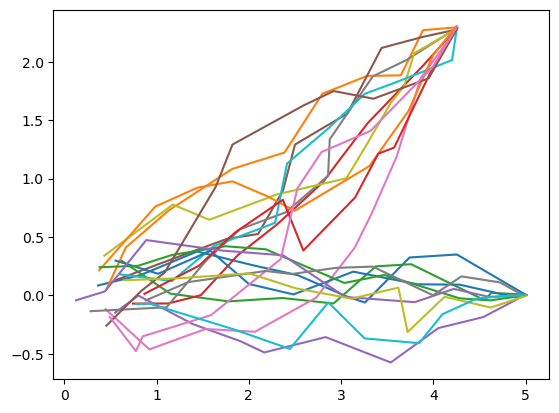

In [2]:

Xtest, _ = sample_mixture(20)
for i in range(Xtest.shape[0]):
    traj = Xtest[i].reshape(T,2)
    plt.plot(traj[:,0], traj[:,1])
plt.show()


[EPS 1000] loss=7.7101e-01
[EPS 2000] loss=7.8480e-01
[EPS 3000] loss=7.6990e-01
[EPS 4000] loss=7.8043e-01
[EPS 5000] loss=7.4424e-01
[EPS 6000] loss=7.5195e-01
[EPS 7000] loss=7.6847e-01
[EPS 8000] loss=7.5217e-01
[EPS 9000] loss=7.4387e-01
[EPS 10000] loss=7.3695e-01
[EPS 11000] loss=7.4319e-01
[EPS 12000] loss=7.2851e-01
[EPS 13000] loss=7.7205e-01
[EPS 14000] loss=7.1337e-01
[EPS 15000] loss=7.1700e-01
[EPS 16000] loss=7.3462e-01
[EPS 17000] loss=7.2365e-01
[EPS 18000] loss=7.2300e-01
[EPS 19000] loss=7.2548e-01
[EPS 20000] loss=7.5323e-01
[EPS 21000] loss=7.3116e-01
[EPS 22000] loss=7.2924e-01
[EPS 23000] loss=7.1603e-01
[EPS 24000] loss=7.2317e-01
[EPS 25000] loss=7.1739e-01
[EPS 26000] loss=7.4520e-01
[EPS 27000] loss=7.2078e-01
[EPS 28000] loss=7.3078e-01
[EPS 29000] loss=7.2413e-01
[EPS 30000] loss=7.1236e-01
[EPS 31000] loss=6.8253e-01
[EPS 32000] loss=7.2326e-01
[EPS 33000] loss=6.7509e-01
[EPS 34000] loss=7.2034e-01
[EPS 35000] loss=7.0560e-01
[EPS 36000] loss=6.9183e-01
[

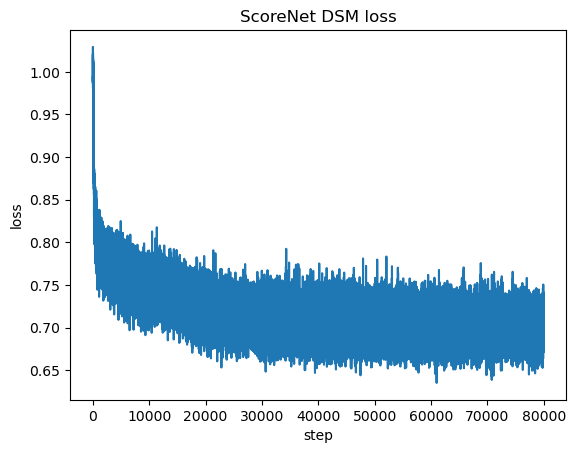

In [9]:
'''
TEACHER MODEL TEST
'''
X_train, _ = sample_mixture(25000) # replace with your function

# 2. Train
score_net, dsm_hist = train_epsnet(Xpool=X_train)
plt.figure(); plt.plot(dsm_hist); plt.title("ScoreNet DSM loss"); plt.xlabel("step"); plt.ylabel("loss"); plt.show()
teacher = score_net

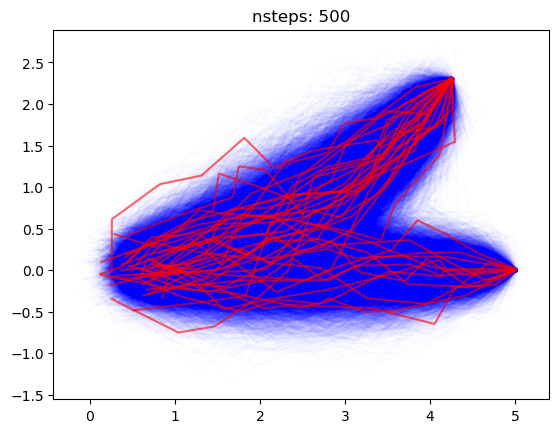

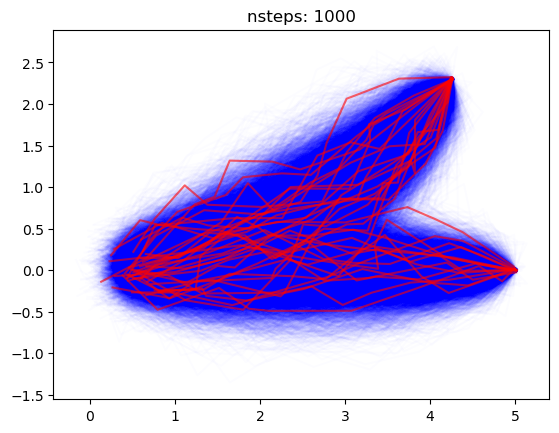

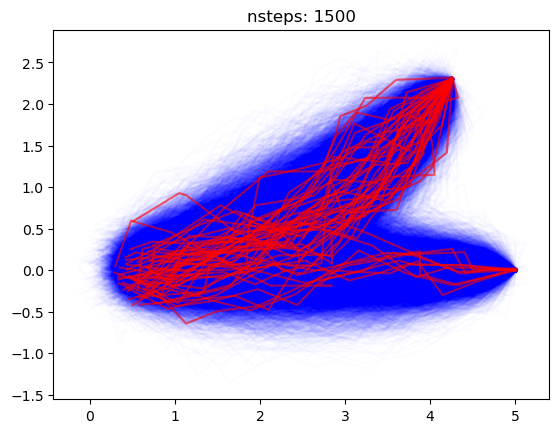

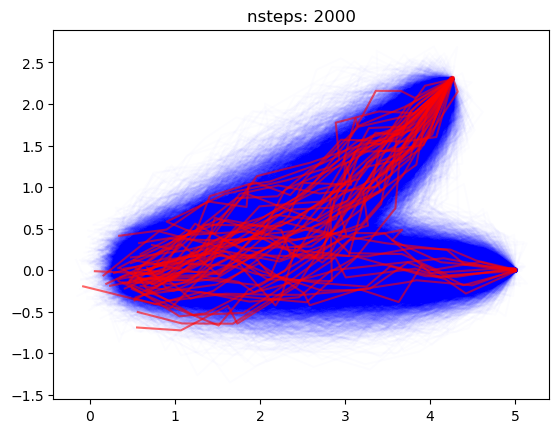

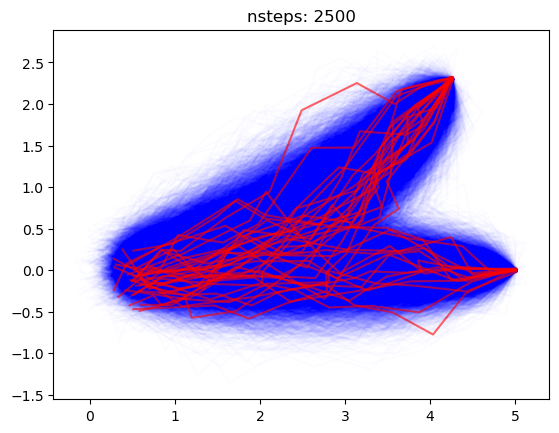

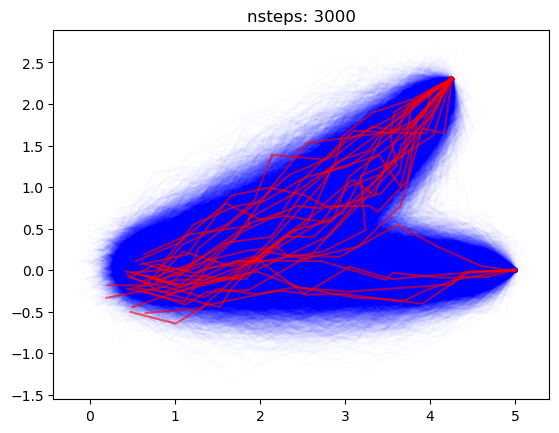

In [10]:
# 3. Sample new trajectories
n_samples = 100

for n_steps in range(500, 3001, 500):
    samples = sample(score_net, n_samples=n_samples, n_steps=n_steps)
    samples = samples.reshape(n_samples, T, 2)  # reshape to (num_samples, T, 2)



    # for i in range(X_train.shape[0]):
    #     traj = X_train[i].reshape(T,2)
    #     plt.plot(traj[:,0], traj[:,1])
    # plt.show()

    for i in range(X_train.shape[0]):
        traj = X_train[i].reshape(T,2)
        plt.plot(traj[:,0], traj[:,1], alpha=0.01, color='blue')
    for traj in samples:
        plt.plot(traj[:,0], traj[:,1], alpha=0.6, color='red')
    plt.title(f"nsteps: {n_steps}")
    plt.show()

# CHECKPOINT

Scenario:  mid_peak


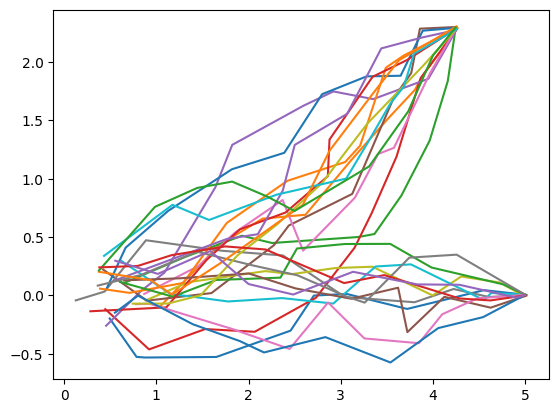

In [2]:
print("Scenario: ", SCENARIO)
N_s = 25
Y_vis, lbl = sample_mixture(N_s)
# Y_vis = whiten(Y_vis)
# Xpool_original = Xpool / W_VEC.astype(np.float32)
# for i in range(Xpool_original.shape[0]):
#     traj = Xpool_original[i].reshape(T,2)
#     # print(traj)
#     # plt.plot(traj)
#     plt.plot(traj[:,0], traj[:,1])
# plt.show()

for i in range(N_s):
    traj = Y_vis[i].reshape(T,2)
    plt.plot(traj[:,0], traj[:,1])
plt.show()
# Y_vis = sample_circle(2000, radius=2.0, noise=0.02)
# plt.scatter(Y_vis[:,0], Y_vis[:,1])


[CONFIG] SCENARIO=mid_peak, NUM_TUBES=50, WHITEN=True
[WHITEN] median std: 0.2563800331295923 min: 0.007992394827623855 max: 0.3168459921650229
Whitener done
(25000, 20)
Step 500, loss=0.9890, sigma=0.1036, lr=9.98e-05
Step 1000, loss=0.9833, sigma=0.1019, lr=9.94e-05
Step 1500, loss=0.9823, sigma=0.1077, lr=9.86e-05
Step 2000, loss=0.9907, sigma=0.1065, lr=9.76e-05
Step 2500, loss=0.9982, sigma=0.1070, lr=9.62e-05
Step 3000, loss=0.9972, sigma=0.1110, lr=9.46e-05
Step 3500, loss=0.9702, sigma=0.1030, lr=9.27e-05
Step 4000, loss=0.9857, sigma=0.1040, lr=9.05e-05
Step 4500, loss=0.9510, sigma=0.1085, lr=8.81e-05
Step 5000, loss=0.9714, sigma=0.1106, lr=8.55e-05
Step 5500, loss=0.9568, sigma=0.1163, lr=8.26e-05
Step 6000, loss=0.9615, sigma=0.1083, lr=7.96e-05
Step 6500, loss=0.9887, sigma=0.1208, lr=7.64e-05
Step 7000, loss=0.9684, sigma=0.1042, lr=7.30e-05
Step 7500, loss=0.9665, sigma=0.1003, lr=6.94e-05
Step 8000, loss=0.9600, sigma=0.1092, lr=6.58e-05
Step 8500, loss=0.9718, sigma=0

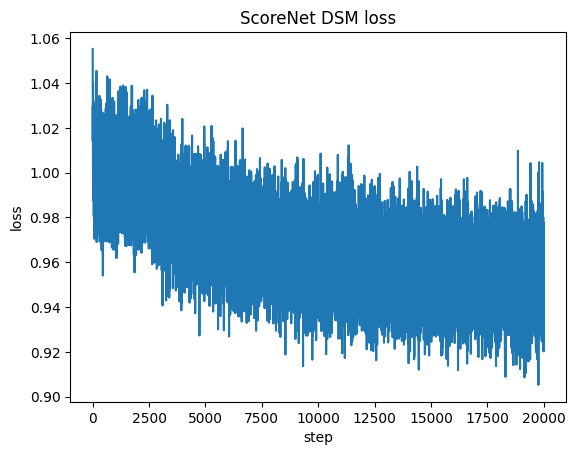

In [ ]:
'''delete this'''
print(f"[CONFIG] SCENARIO={SCENARIO}, NUM_TUBES={NUM_TUBES}, WHITEN={WHITEN}")
if WHITEN:
    fit_whitener()
    print("Whitener done");

# Train ScoreNet (teacher) + PrecisionHead
teacher = None
if USE_SCORENET_TEACHER:
    score_net, dsm_hist = train_scorenet()
    plt.figure(); plt.plot(dsm_hist); plt.title("ScoreNet DSM loss"); plt.xlabel("step"); plt.ylabel("loss"); plt.show()
    teacher = score_net

[CONFIG] SCENARIO=mid_peak, NUM_TUBES=50, WHITEN=True
[WHITEN] median std: 0.31821385093259014 min: 0.1693710041122026 max: 1.14030771453692
Whitener done
[EPS 1000] loss=8.9948e-01
[EPS 2000] loss=8.9527e-01
[EPS 3000] loss=8.9731e-01
[EPS 4000] loss=9.0157e-01
[EPS 5000] loss=8.7630e-01
[EPS 6000] loss=8.7961e-01
[EPS 7000] loss=8.9410e-01
[EPS 8000] loss=8.8952e-01
[EPS 9000] loss=8.8213e-01
[EPS 10000] loss=8.7668e-01
[EPS 11000] loss=8.7416e-01
[EPS 12000] loss=8.7371e-01
[EPS 13000] loss=8.9909e-01
[EPS 14000] loss=8.6868e-01
[EPS 15000] loss=8.5772e-01
[EPS 16000] loss=8.8094e-01
[EPS 17000] loss=8.8059e-01
[EPS 18000] loss=8.7880e-01
[EPS 19000] loss=8.5185e-01
[EPS 20000] loss=8.9285e-01
[EPS 21000] loss=8.7410e-01
[EPS 22000] loss=8.6502e-01
[EPS 23000] loss=8.5399e-01
[EPS 24000] loss=8.5951e-01
[EPS 25000] loss=8.3657e-01
[EPS 26000] loss=8.6995e-01
[EPS 27000] loss=8.7418e-01
[EPS 28000] loss=8.9023e-01
[EPS 29000] loss=8.7256e-01
[EPS 30000] loss=8.5056e-01
[EPS 31000] lo

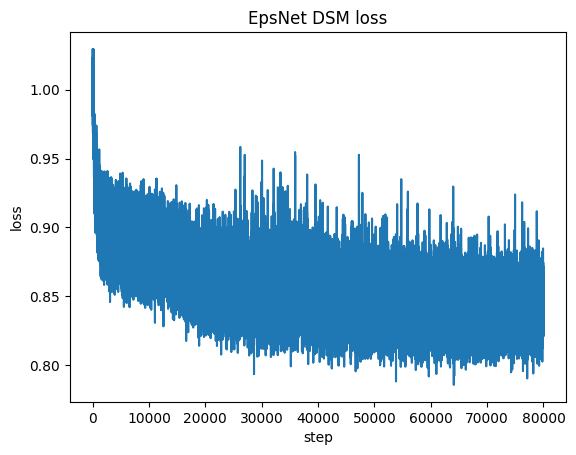

[PH  100] L_prec=1.2124e+04  (reg≈1.60e+02)
[PH  200] L_prec=9.5285e+03  (reg≈1.26e+02)
[PH  300] L_prec=7.8645e+03  (reg≈1.21e+02)
[PH  400] L_prec=1.8828e+04  (reg≈1.01e+02)
[PH  500] L_prec=5.5067e+03  (reg≈1.08e+02)
[PH  600] L_prec=6.0367e+03  (reg≈1.03e+02)
[PH  700] L_prec=1.1665e+04  (reg≈8.74e+01)
[PH  800] L_prec=4.6233e+03  (reg≈8.81e+01)
[PH  900] L_prec=5.3426e+03  (reg≈8.17e+01)
[PH 1000] L_prec=8.6983e+03  (reg≈6.85e+01)


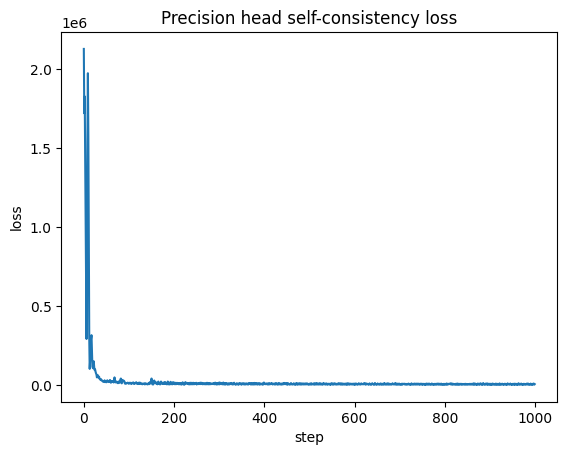

In [3]:
# ------------------------------
# Train the score model and the prediction head.
# ------------------------------

print(f"[CONFIG] SCENARIO={SCENARIO}, NUM_TUBES={NUM_TUBES}, WHITEN={WHITEN}")
if WHITEN:
    fit_whitener()
    print("Whitener done");

# Train ScoreNet (teacher) + PrecisionHead
teacher = None
if USE_SCORENET_TEACHER:
    score_net, dsm_hist = train_scorenet()
    plt.figure(); plt.plot(dsm_hist); plt.title("ScoreNet DSM loss"); plt.xlabel("step"); plt.ylabel("loss"); plt.show()
    teacher = score_net
elif USE_EPSNET_TEACHER:
    eps_net, dsm_hist = train_epsnet()
    plt.figure(); plt.plot(dsm_hist); plt.title("EpsNet DSM loss"); plt.xlabel("step"); plt.ylabel("loss"); plt.show()
    teacher = eps_net

head, ph_hist = train_precision_head(teacher=teacher)
plt.figure(); plt.plot(ph_hist); plt.title("Precision head self-consistency loss"); plt.xlabel("step"); plt.ylabel("loss"); plt.show()





In [4]:
# -------- Calibration set (precompute m2) --------
CAL_SCENES = 300      # reduce if needed for faster turnaround but poorer calibration.
start = time.time()
Yp_cal, Yt_cal, m2_cal = precompute_union_m2(head, n_scenes=CAL_SCENES, num_tubes=NUM_TUBES, diversify=True,
                                             diversify_mode="waypoints", batch=2048)
print(f"[TIME] precompute (cal) {time.time()-start:.2f}s")

# Per-horizon UNION calibration via closed-form quantiles
s_table = calibrate_union_per_horizon_quantile(m2_cal, alphas=ALPHAS_GRID)

# PATH γ(α) via closed-form quantiles
gamma_vec = calibrate_union_path_gamma_quantile(m2_cal, s_table, alphas=ALPHAS_GRID)
print("[CALIBRATION] s_table shape:", s_table.shape, " gamma_vec:", gamma_vec)


[PRECOMPUTE] Union m2 computed for 300 scenes x 50 tubes in 68.78s
[TIME] precompute (cal) 68.81s
[CALIBRATION] s_table shape: (10, 5)  gamma_vec: [6.79771868 5.45774459 4.78466131 3.99752062 3.48391262]


[PRECOMPUTE] Union m2 computed for 300 scenes x 50 tubes in 67.90s


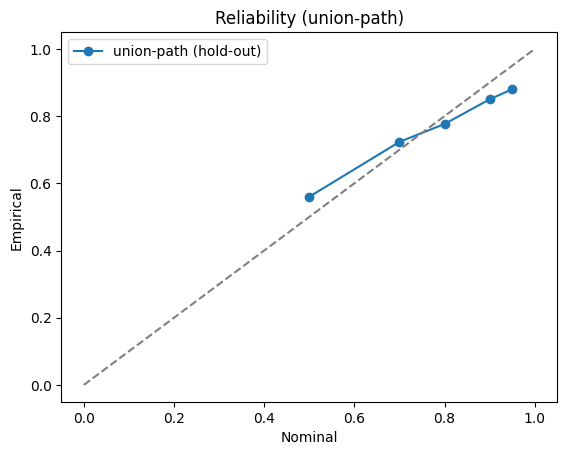

Nominal 50% -> Empirical 56.00%
Nominal 70% -> Empirical 72.33%
Nominal 80% -> Empirical 77.67%
Nominal 90% -> Empirical 85.00%
Nominal 95% -> Empirical 88.00%


In [5]:
# -------- Hold-out evaluation (recommended) --------
EVAL_SCENES = 300
Yp_eval, Yt_eval, m2_eval = precompute_union_m2(head, n_scenes=EVAL_SCENES, num_tubes=NUM_TUBES, diversify=True,
                                                diversify_mode="waypoints", batch=2048)

alphas_test = [0.50, 0.70, 0.80, 0.90, 0.95]
cov_emp = []
for a in alphas_test:
    cov = evaluate_union_path_from_m2(m2_eval, s_table, gamma_vec, alpha=a)
    cov_emp.append(cov)
plt.figure()
plt.plot(alphas_test, cov_emp, marker='o', label='union-path (hold-out)')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("Nominal"); plt.ylabel("Empirical"); plt.title("Reliability (union-path)"); plt.legend(); plt.show()
for a,c in zip(alphas_test, cov_emp):
    print(f"Nominal {int(100*a)}% -> Empirical {100*c:.2f}%")

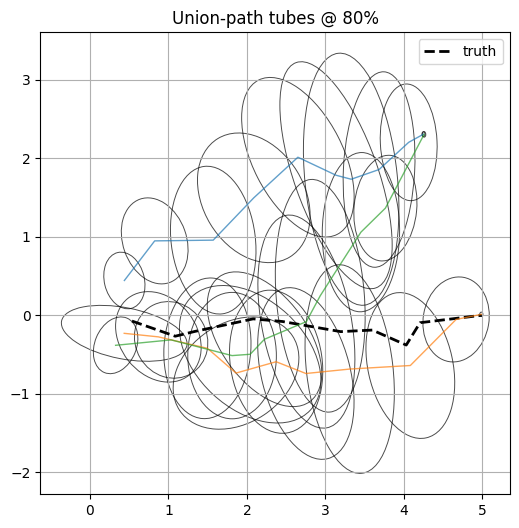

In [23]:
# -------- Visualization on a few scenes --------
alp = 0.80
# Pick a random eval scene and visualize up to 8 tubes
# this will oook like a big mess. :P
idx = np.random.randint(EVAL_SCENES)
s_vec = s_table[:, int(np.argmin(np.abs(ALPHAS_GRID - alp)))]
gamma = float(gamma_vec[int(np.argmin(np.abs(ALPHAS_GRID - alp)))])

plot_scene_union_tubes(head, Yp_eval[idx], Yt_eval[idx], alpha=alp, s_vec=s_vec, gamma=gamma,
                       max_tubes_show=min(3, NUM_TUBES),
                       title=f"Union-path tubes @ {int(100*alp)}%")


In [7]:
# ------------------------------
# Union-path visualization (single tube)
# ------------------------------

# ---------- helper: evaluate head and return factors in float64 ----------

# ---------- banded solves + 2x2 marginal from (A + R R^T)^{-1} ----------
def solve_band_cholesky(L, B):
    """Solve (LL^T) X = B for X with triangular solves (banded L)."""
    Z = torch.linalg.solve_triangular(L, B, upper=False)
    return torch.linalg.solve_triangular(L.t(), Z, upper=True)

def block_marginal_from_factors(
    L, R, t,
    eps_M=None,              # jitter for the small (r x r) Woodbury system
    eigen_floor=1e-9,        # clamp tiny eigenvalues for PSD safety
    precision_ridge=None     # λ for A <- A + λ I (use when Cholesky is touchy)
):
    """
    Extract 2x2 marginal S_t from Σ = (A + R R^T)^{-1}, with A = L L^T (block-tridiag).
    Works with/without low-rank tail R. Handles dtype/device mismatches.
    """
    # defaults from your globals if present
    if eps_M is None:
        eps_M = globals().get('WOODBURY_JITTER', 1e-6)
    if precision_ridge is None:
        precision_ridge = globals().get('PRECISION_RIDGE', 0.0)

    Dloc = L.shape[0]
    # harmonize R dtype/device
    if (R is not None) and (getattr(R, "numel", lambda: 0)() > 0):
        if R.dtype != L.dtype or R.device != L.device:
            R = R.to(dtype=L.dtype, device=L.device)

    # selection matrix columns for the (x_t, y_t) block
    i, j = 2*t, 2*t+1
    E = torch.zeros(Dloc, 2, dtype=L.dtype, device=L.device)
    E[i,0] = 1.0; E[j,1] = 1.0

    # two paths: (A + λI) exact via dense chol, else fast banded A^{-1}
    if precision_ridge and precision_ridge > 0.0:
        A = L @ L.t() + precision_ridge * torch.eye(Dloc, dtype=L.dtype, device=L.device)
        Ld = torch.linalg.cholesky(A)
        Z  = torch.cholesky_solve(E, Ld)  # (A+λI)^{-1} E
        if (R is None) or (getattr(R, "numel", lambda: 0)() == 0):
            X = Z
        else:
            AinvR = torch.cholesky_solve(R, Ld)        # (A+λI)^{-1} R
            RtZ   = R.t() @ Z
            M     = torch.eye(R.shape[1], dtype=L.dtype, device=L.device) + R.t() @ AinvR
            M     = 0.5*(M + M.t()) + eps_M * torch.eye(M.shape[0], dtype=L.dtype, device=L.device)
            W     = torch.linalg.solve(M, RtZ)
            X     = Z - AinvR @ W
    else:
        Z = solve_band_cholesky(L, E)  # A^{-1} E
        if (R is None) or (getattr(R, "numel", lambda: 0)() == 0):
            X = Z
        else:
            AinvR = solve_band_cholesky(L, R)        # A^{-1} R
            RtZ   = R.t() @ Z
            M     = torch.eye(R.shape[1], dtype=L.dtype, device=L.device) + R.t() @ AinvR
            M     = 0.5*(M + M.t()) + eps_M * torch.eye(M.shape[0], dtype=L.dtype, device=L.device)
            W     = torch.linalg.solve(M, RtZ)
            X     = Z - AinvR @ W

    # 2x2 marginal
    S = X[i:j+1, :]
    S = 0.5*(S + S.t())

    # optional 2x2 ridge on the marginal (leave at 0 unless you really need it)
    block_ridge = float(globals().get('BLOCK_RIDGE', 0.0))
    if block_ridge > 0.0:
        Sinv = torch.linalg.inv(S)
        S    = torch.linalg.inv(Sinv + block_ridge * torch.eye(2, dtype=S.dtype, device=S.device))

    # PSD clamp in numpy for robustness
    S_np = S.detach().cpu().numpy()
    w, V = np.linalg.eigh(0.5*(S_np + S_np.T))
    w = np.clip(w, eigen_floor, None)
    S_np = (V * w) @ V.T
    return torch.from_numpy(S_np).to(dtype=L.dtype, device=L.device)


def _module_dtype_device(mod):
    # robustly get dtype/device even if the module has no parameters yet
    for p in mod.parameters():
        return p.dtype, p.device
    for b in mod.buffers():
        return b.dtype, b.device
    return torch.float32, torch.device('cpu')

def _head_factors_eval(head, Y_white_numpy):
    """
    Y_white_numpy: np.ndarray of shape [B, D] in the *whitened* space when WHITEN=True.
    Returns:
      L_list: list of B lower-triangular banded Cholesky factors (torch.float64)
      R_list: list of B low-rank tails or None (torch.float64)
    """
    dtype, device = _module_dtype_device(head)
    Y_t = torch.from_numpy(np.asarray(Y_white_numpy)).to(device=device, dtype=dtype)
    with torch.no_grad():
        L_list, R_list = head(Y_t)
    # Force double for stable downstream linear algebra
    L_list = [L.to(torch.float64) for L in L_list]
    R_list = [(R.to(torch.float64) if (R is not None) else None) for R in R_list]
    return L_list, R_list

def chi2_ppf_df2(alpha: float) -> float:
    return -2.0 * math.log(max(1e-16, 1.0 - alpha))

# def mahalanobis_sq(diff, S):
#     L = np.linalg.cholesky(S)
#     y = np.linalg.solve(L, diff)
#     return float((y.T @ y).item())

def mahalanobis_sq(diff, S, floor=1e-12):
    # robust 2D Mahalanobis without Cholesky; clamps eigenvalues
    w, V = np.linalg.eigh(0.5*(S + S.T))
    w = np.clip(w, floor, None)
    q = V.T @ diff
    return float((q[0]*q[0]/w[0]) + (q[1]*q[1]/w[1]))



def _select_union_path_tube(head, Yp_scene, Yt_scene, alpha, s_vec, gamma):
    """
    Pick the single tube minimizing the union-path objective:
        k* = argmin_k max_t m^2_{ikt} / tau_alpha,
    where m^2 uses the *scaled* covariances (gamma * s_t)^2 S_{kt}.
    Returns (k_best, L_best, R_best, norm_m2_t) where norm_m2_t[t] = m^2/tau.
    """
    M = Yp_scene.shape[0]
    tau = chi2_ppf_df2(alpha)

    # factors for all candidates (whitened)
    Yp_w = whiten(Yp_scene) if WHITEN else Yp_scene
    L_list, R_list = _head_factors_eval(head, Yp_w)

    best_k, best_max, best_curve = 0, float('inf'), None
    for k in range(M):
        norm_m2_t = []
        for t in range(T):
            S_w = block_marginal_from_factors(L_list[k], R_list[k], t).cpu().numpy()
            S_w = (float(gamma * s_vec[t])**2) * S_w
            S   = unwhiten_block(S_w, t) if WHITEN else S_w
            diff = (Yt_scene.reshape(T,2)[t] - Yp_scene[k].reshape(T,2)[t])
            m2   = mahalanobis_sq(diff, S)
            norm_m2_t.append(m2 / tau)
        max_norm = float(np.max(norm_m2_t))
        if max_norm < best_max:
            best_max, best_k, best_curve = max_norm, k, np.asarray(norm_m2_t, dtype=np.float64)

    return best_k, L_list[best_k], R_list[best_k], best_curve


def plot_best_union_path_tube(head, Yp_scene, Yt_scene, alpha, s_vec, gamma,
                              stride=None, title=None):
    """
    Show ONE tube (union-path winner) with its ellipses + a side panel:
      - left: selected tube + truth + a few ellipses (every 'stride' steps)
      - right: major/minor radii and normalized m^2/tau across time

    Args:
      Yp_scene: (M, D) candidates for the scene
      Yt_scene: (D,) ground truth for the scene
      alpha:    coverage level (e.g., 0.90)
      s_vec:    per-horizon scales s_t(alpha)  [shape: (T,)]
      gamma:    path multiplier γ(alpha)       [scalar]
      stride:   plot an ellipse every 'stride' steps (defaults to ~6 ellipses total)
    """
    if stride is None:
        stride = max(1, T // 6)

    k_best, Lb, Rb, norm_m2_t = _select_union_path_tube(head, Yp_scene, Yt_scene, alpha, s_vec, gamma)
    tube = Yp_scene[k_best].reshape(T,2)
    truth = Yt_scene.reshape(T,2)
    tau = chi2_ppf_df2(alpha); rad = math.sqrt(tau)

    # Precompute radii across time for the selected tube
    major, minor = [], []
    for t in range(T):
        S_w = block_marginal_from_factors(Lb, Rb, t).cpu().numpy()
        S_w = (float(gamma * s_vec[t])**2) * S_w
        S   = unwhiten_block(S_w, t) if WHITEN else S_w
        w, V = np.linalg.eigh(0.5*(S + S.T))
        w = np.clip(w, 1e-12, None)
        # radii at level alpha (ellipse semi-axes)
        r1, r0 = rad*np.sqrt(w[1]), rad*np.sqrt(w[0])
        major.append(r1); minor.append(r0)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
    ax = axes[0]

    # Mean paths
    ax.plot(tube[:,0],  tube[:,1],  lw=1.6, label='selected tube')
    ax.plot(truth[:,0], truth[:,1], '--', color='k', lw=1.2, label='truth')

    # Ellipses every 'stride' steps
    for t in range(0, T, stride):
        S_w = block_marginal_from_factors(Lb, Rb, t).cpu().numpy()
        S_w = (float(gamma * s_vec[t])**2) * S_w
        S   = unwhiten_block(S_w, t) if WHITEN else S_w
        w, V = np.linalg.eigh(0.5*(S + S.T)); w = np.clip(w, 1e-12, None)
        width, height = 2*rad*np.sqrt(w[1]), 2*rad*np.sqrt(w[0])
        angle = math.degrees(math.atan2(V[1,1], V[0,1]))
        e = Ellipse(xy=tube[t], width=width, height=height, angle=angle,
                    facecolor='none', edgecolor='C0', lw=1.0, alpha=0.9)
        ax.add_patch(e)

    ax.set_aspect('equal', 'box'); ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    if title: ax.set_title(title)

    # Right panel: ellipse radii + normalized error
    tgrid = np.arange(T)
    ax2 = axes[1]
    ax2.plot(tgrid, major, label='major radius', lw=1.5)
    ax2.plot(tgrid, minor, label='minor radius', lw=1.5)
    ax2.plot(tgrid, norm_m2_t, label=r'$m^2/\tau_\alpha$', lw=1.5)
    ax2.axhline(1.0, ls='--', color='gray', lw=1.0)
    ax2.set_xlabel('time'); ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)
    ax2.set_title('Ellipse size + normalized error')

    plt.tight_layout(); plt.show()


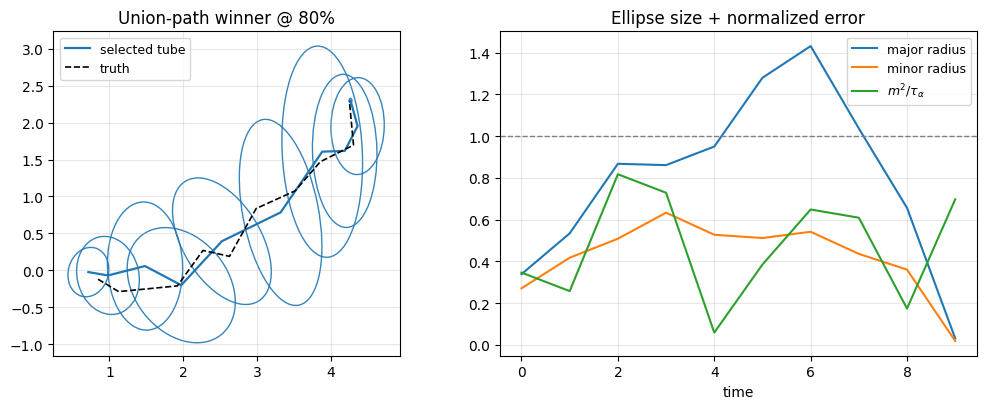

In [20]:
# One random scene
idx = np.random.randint(EVAL_SCENES)
s_vec  = s_table[:, int(np.argmin(np.abs(ALPHAS_GRID - alp)))]
gamma0 = float(gamma_vec[int(np.argmin(np.abs(ALPHAS_GRID - alp)))])

plot_best_union_path_tube(
    head,
    Yp_eval[idx],            # (M, D)
    Yt_eval[idx],            # (D,)
    alpha=alp,
    s_vec=s_vec,
    gamma=gamma0,
    stride=max(1, T//6),     # ~6 ellipses total
    title=f"Union-path winner @ {int(100*alp)}%"
)
